In [65]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

connection=sqlite3.connect('../data/checking-logs.sqlite')

In [66]:
query = '''
SELECT uid, timestamp, numTrials FROM checker
WHERE uid LIKE 'user_%' AND status="ready" AND labname="project1"
'''

df = pd.read_sql(sql=query, con=connection, parse_dates=['timestamp'])
df

,uid,timestamp,numTrials
0,user_4,2020-04-17 05:19:02.744528,1
1,user_4,2020-04-17 05:22:45.549397,2
2,user_4,2020-04-17 05:34:24.422370,3
3,user_4,2020-04-17 05:43:27.773992,4
4,user_4,2020-04-17 05:46:32.275104,5
...,...,...,...
946,user_19,2020-05-15 10:22:39.698523,26
947,user_19,2020-05-15 10:22:46.248162,27
948,user_19,2020-05-15 10:23:18.043212,28
949,user_28,2020-05-15 10:38:14.430013,27


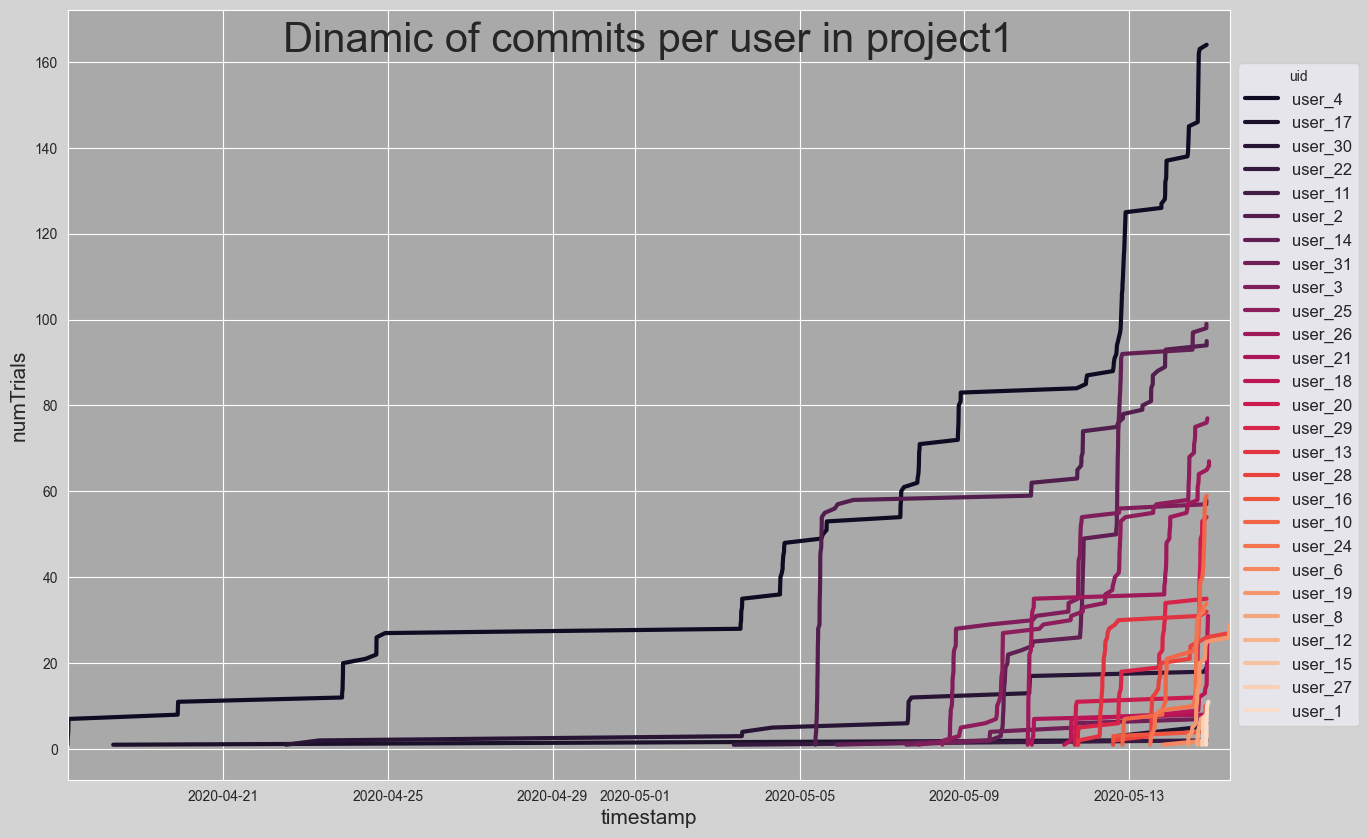

In [78]:
fig, ax = plt.subplots(figsize=(15, 10))
fig.set_facecolor('lightgray')
ax.set_facecolor('darkgray')

sns.lineplot(data=df, x='timestamp', y='numTrials', hue='uid', palette='rocket', linewidth=3, ax=ax)

xmin = df['timestamp'].min()
xmax = df['timestamp'].max()
ax.set_xlim(xmin, xmax)

ax.set_title('Dinamic of commits per user in project1', fontsize=30, pad=-30)
ax.set_xlabel('timestamp',fontsize=15)
ax.set_ylabel('numTrials',fontsize=15)

legend = ax.legend(title='uid', bbox_to_anchor=(1, 0.5), loc='center left', fontsize=12)
plt.show()

In [68]:
connection.close()

«Какой пользователь почти все время лидировал по количеству коммитов?» Ответ: user_*. **user_4**  
«Какой пользователь лидировал лишь в течение короткого периода времени?» Ответ: user_*. **user_2**